# Toy System
## System definition
Let $E=[-2,2]$ and let $\nu$ be a probability measure supported on $E$.

Define the process $(X_t)_{t\ge0}$ by:

- **Flow.** For $x\in(-2,2)$,
  $$
  \dot{x}=f(x)=x,\qquad \phi(t,x)=x e^{t}.
  $$

- **Boundary hitting time.**
  $$
  \tau(x)=\inf\{t>0:\phi(t,x)\in\{-1,1\}\}=\ln\!\big(\tfrac{1}{|x|}\big)\quad (x\neq0),
  $$
  and $\tau(0)=+\infty$.

- **Reinsertion rule.** Whenever $X_t$ reaches $\{-2,2\}$ it is instantaneously reset to a random point
  $$
  X_t\sim\nu,
  $$
  independent of the past. Equivalently the jump kernel satisfies $Q(x,A)=\nu(A)$ for $x\in\{-1,1\}$ and Borel $A\subseteq[-1,1]$.

Hence $(X_t)$ is a piecewise-deterministic Markov process on $E$ with flow $f(x)=x$ and reset law $\nu$.


In [60]:
import matplotlib.pyplot as plt
import importlib
import cdv_utils
import numpy as np
from scipy import sparse
import pickle


importlib.reload(cdv_utils)

/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py:1829: SyntaxWarning: invalid escape sequence '\s'
  Works with samplers that expect `size` as a tuple.


<module 'cdv_utils' from '/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py'>

In [61]:
from cdv_utils import (plot_lifetime_distributions_lines, diffusion_maps_matrix,
                       expected_escape_times_from_TO, add_scaled_top_axis,
                       spy_col, simulate_trajectories_per_sigma,
                       uniform_reset_sampler_vectorized,
                       uniform_radius_sampler_vectorized,
                       plot_trajectory_with_reinsertions, plot_multiple_sigmas,
                       plot_multiple_trajectories, estimate_pdf_from_sampler,
                       plot_multiple_trajectories_with_pdf_strip,
                       compute_lifetimes_per_sigma,
                       compute_lifetimes_per_sigma_old,
                       constant_reset_sampler_factory,
                       mean_escape_times_via_reinsertion_points,
                       plot_mean_escape_by_reinsertion, f_scientific,
                       tail_integrand_asym,
                       diffusion_maps_matrix_1d,
                       expected_escape_times_from_TO_fast)

In [62]:
dt = 1e-2
save_every = 1
sigmas = np.linspace(0.0, 0.5, 101, dtype=np.float32)
rng = np.random.default_rng(6942)

In [63]:
times, states, sigma_arr = simulate_trajectories_per_sigma(
    sigmas=np.array([0.0], dtype=np.float32),
    dt=dt,
    n_steps=int(1e3) - 1,
    reset_sampler=lambda rng, size: uniform_radius_sampler_vectorized(
        rng, size, low=0.01, high=0.1
    ),
    rng=rng,
    save_every=save_every,
    x0=0.01,
    dtype=np.float32
)

<Axes: title={'center': 'Trajectory with reinsertion on |x|≥1'}, xlabel='time', ylabel='x(t)'>

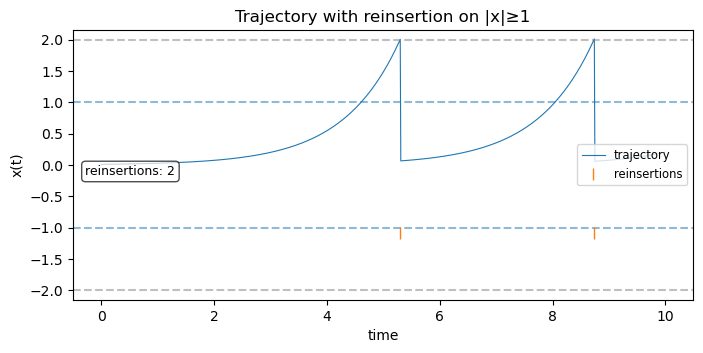

In [64]:
fig, ax = plt.subplots(figsize=(8, 3.5))
reset_times_per_path = [
    times[np.abs(states[:, j]) > 2] for j in range(states.shape[1])]
plot_trajectory_with_reinsertions(
    ax, times, states, reset_times_per_path[0])

## Stochastic Trajectory

In [65]:
# keep rng the same for comparability
rng = np.random.default_rng(6942)  # 4242
times, states, sigma_arr = simulate_trajectories_per_sigma(
    # single sigma -> single column
    sigmas=sigmas,
    dt=dt,
    n_steps=int(1e3) - 1,
    reset_sampler=lambda rng, size: uniform_radius_sampler_vectorized(
        rng, size, low=0.01, high=0.1
    ),
    rng=rng,
    save_every=save_every,
    x0=0.05,
    dtype=np.float32
)

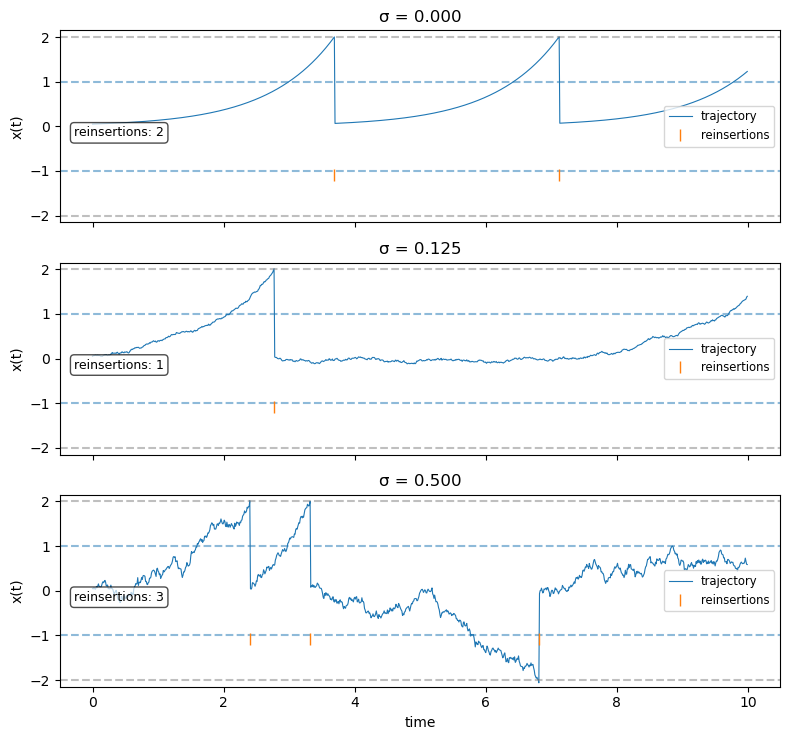

In [66]:
reset_times_per_path = [
    times[np.abs(states[:, j]) > 2] for j in [0, 25, 100]]

plot_multiple_sigmas(times, states[:, [0, 25, 100]],
                     sigma_arr[[0, 25, 100]],
                     n_cols=1, figsize=(8, 2.5), reset_times_per_path=reset_times_per_path)

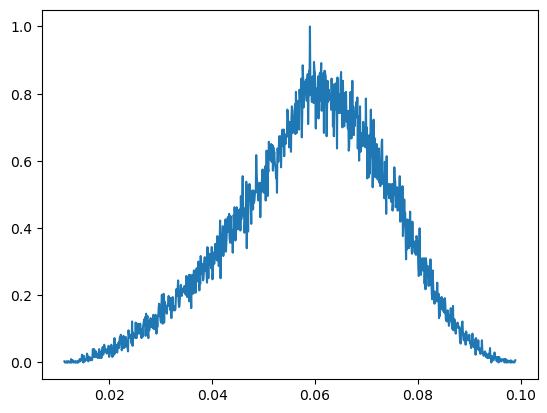

In [67]:
bins, pdf = estimate_pdf_from_sampler(
    uniform_radius_sampler_vectorized,
    rng,
    n_bins=1000,
    sampler_kwargs={'low': 0.01, 'high': 0.1}
)
plt.plot(bins, pdf)
# plt.gca().set_xlim(0.05, 0.1)

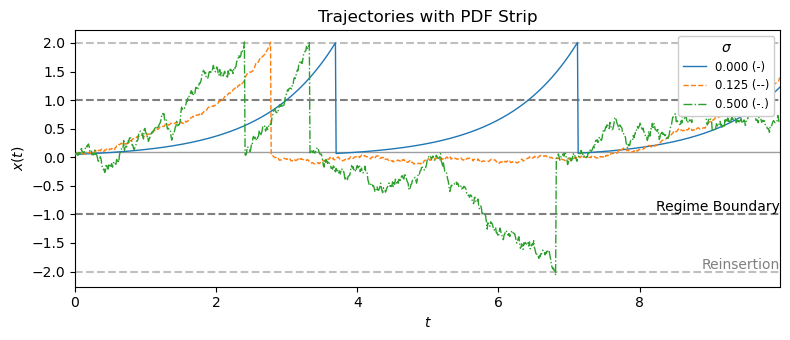

In [68]:
bins, pdf = estimate_pdf_from_sampler(
    uniform_radius_sampler_vectorized,
    rng,
    n_bins=1000,
    sampler_kwargs={'low': 0.05, 'high': 0.1}
)

ax = plot_multiple_trajectories_with_pdf_strip(
    ax=None, times=times, states=states[:, [0, 25, 100]],
    labels=[f"{sigma_arr[i]:.3f}" for i in [0, 25, 100]], pdf_bins=bins, pdf_values=pdf,
    title="Trajectories with PDF Strip")

# ax.set_ylim([0, 0.2])

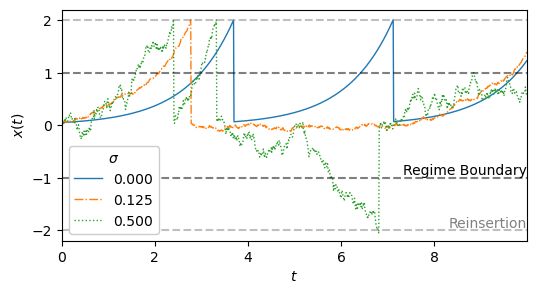

In [69]:
fig, ax = plot_multiple_trajectories(ax=None, times=times,
                                     states=states[:, [
                                         0, 25, 100]],
                                     labels=[
                                         f"{sigma_arr[i]:.3f}"
                                         for i in [0, 25, 100]],
                                     text_loc="right")
ax.set_xlim(0, times[-1])
plt.savefig("../../Toy.pdf", dpi=600, bbox_inches="tight")

## Stochastic Inertia for individual points

### Monte Carlo Method
- use long trajectories for convergence

In [70]:
# 3 mins
reinsertion_points = np.linspace(0.01, 0.1, 4)
means, counts = mean_escape_times_via_reinsertion_points(
    sigmas=sigmas,
    reinsertion_points=reinsertion_points,
    dt=dt,
    n_steps=int(1e7) - 1,
    rng=rng,
    save_every=save_every,
    dtype=np.float32
)

### Analytic

In [71]:
means_ana = np.empty_like(means)

for i, x in enumerate(reinsertion_points):
    means_ana[:, i] = [f_scientific(x, .5 * sigma**2) for sigma in sigmas]

### Markov Method
- use lower dt for convergence

In [72]:
dt_lower = 5e-4
times, states, sigma_arr = simulate_trajectories_per_sigma(
    sigmas=np.array([0.0], dtype=np.float32),
    dt=dt_lower,
    n_steps=100000 - 1,
    reset_sampler=constant_reset_sampler_factory(0.05, dtype=np.float32),
    rng=rng,
    save_every=save_every,
    x0=reinsertion_points[0],
    dtype=np.float32
)

In [73]:
first_reset = np.where(np.abs(states[:, 0]) > 2)[0][0]
mini_traj = states[:first_reset, 0]
rp_idx = [np.argmin(np.abs(mini_traj - rp))
          for rp in reinsertion_points]

In [74]:
mini_traj.shape

(10597,)

In [75]:
# 4 min
eps_values = (2 * (dt_lower) * sigmas**2)
blocking_mask = np.where(np.abs(mini_traj) < 1.0)[0]
reinsert_TO = np.empty(
    (sigmas.size, reinsertion_points.size), dtype=np.float64)
for j, eps in enumerate(eps_values):
    DMM, A = diffusion_maps_matrix_1d(mini_traj, eps)
    L = sparse.vstack(
        [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')
    Q = L[blocking_mask][:, blocking_mask].tocsr()
    I = sparse.eye(Q.shape[0], format='csr')
    t_escape = sparse.linalg.spsolve(I - Q, np.ones(Q.shape[0]))
    reinsert_TO[j, :] = t_escape[rp_idx]

/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py:2359: RuntimeWarning: invalid value encountered in divide
  A = sparse.coo_matrix((np.exp(-(vals**2) / epsilon),


### Plot

<>:102: SyntaxWarning: invalid escape sequence '\s'
<>:102: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_38593/113165065.py:102: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")
/tmp/ipykernel_38593/113165065.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


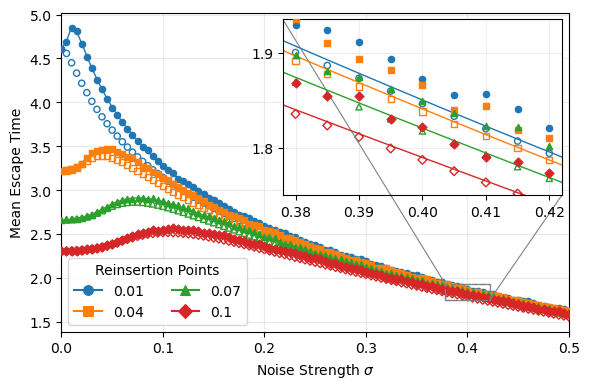

In [76]:
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.patches import Rectangle
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(6)]
markers = ['o', 's', '^', 'D', 'v', 'P']
s = 20
fig, ax = plt.subplots(figsize=(6, 4))

# Plot analytic curves (lines)
for j in range(means_ana.shape[1]):
    ax.plot(sigmas, means_ana[:, j],
            linestyle='-', linewidth=1,
            color=colors[j],
            alpha=1)

# Plot approximations as markers (no connecting line)
for j in range(means.shape[1]):
    ax.scatter(sigmas, means[:, j],
               marker=markers[j],
               s=s,
               linewidths=1,
               edgecolors=colors[j],
               alpha=1,
               label=None, zorder=3)

for j in range(reinsert_TO.shape[1]):
    ax.scatter(
        sigmas,
        reinsert_TO[:, j] * dt_lower,
        marker=markers[j],
        s=s,                    # marker size (points^2) ≈ 6px diameter
        linewidths=1,          # edge thickness
        edgecolors=colors[j],
        facecolors='none',       # hollow marker
        alpha=1,
        label=None
    )  # legend handled below with custom handles

# Build a single legend showing both the color and marker for each reinsertion point
labels = [f"{val:g}" for val in reinsertion_points]
handles = [
    Line2D([0], [0],
           color=colors[i],
           marker=markers[i],
           linestyle='-',
           markersize=7,
           markeredgewidth=0.8)
    for i in range(len(labels))
]

x1, x2, y1, y2 = 0.378, 0.422, 1.75, 1.935
# to demonstrate non-convergence at lower sample size
# x1, x2, y1, y2 = 0.06, .125, 2.5, 3

# create inset axes located at top-right of the main axes (40% of width/height)
axins = inset_axes(ax, width="55%", height="55%", loc="upper right",
                   bbox_to_anchor=(0.0, 0.0, 1, 1), bbox_transform=ax.transAxes)

# set the data limits for the inset
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

for j in range(means_ana.shape[1]):
    axins.plot(sigmas, means_ana[:, j],
               linestyle='-', linewidth=1.0, color=colors[j], alpha=1)
    axins.scatter(sigmas, means[:, j],
                  marker=markers[j],
                  s=s,
                  linewidths=1,
                  edgecolors=colors[j],
                  alpha=1,
                  label=None, zorder=3)
    axins.scatter(
        sigmas,
        reinsert_TO[:, j] * dt_lower,
        marker=markers[j],
        s=s,                    # marker size (points^2) ≈ 6px diameter
        linewidths=1,          # edge thickness
        edgecolors=colors[j],
        facecolors='none',       # hollow marker
        alpha=1,
        label=None
    )

# axins.tick_params(axis='both', which='major', labelsize=8)
axins.grid(alpha=0.2)
axins.xaxis.set_major_locator(plt.MultipleLocator(0.01))
axins.yaxis.set_major_locator(plt.MultipleLocator(0.1))
# draw a rectangle on the main axes showing the inset region
rect = Rectangle((x1, y1), x2 - x1, y2 - y1,
                 linewidth=1.0, edgecolor='gray', facecolor='none', linestyle='--', zorder=5)
ax.add_patch(rect)

# draw connector lines between inset and rectangle (nice visual cue)
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5", linewidth=0.8)


ax.legend(handles, labels, title="Reinsertion Points",
          loc="lower left", frameon=True, ncols=2)

ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Mean Escape Time")
ax.grid(alpha=0.25)
ax.set_xlim(0, 0.5)
plt.tight_layout()
plt.savefig("../../Toy_AnaVSTraj.pdf", dpi=600, bbox_inches="tight")

## Turn to Regime Lifetimes

### Using Monte Carlo

In [29]:
# we want a smooth curve but not too many points
dt_compare = 1e-1
times, states, sigma_arr = simulate_trajectories_per_sigma(
    sigmas=sigmas,
    dt=dt_compare,
    n_steps=int(2e4) - 1,
    reset_sampler=lambda rng, size: uniform_radius_sampler_vectorized(
        rng, size, low=0.01, high=0.1
    ),
    rng=rng,
    save_every=save_every,
    x0=0.05,
    dtype=np.float32
)

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_38593/2926610206.py:4: SyntaxWarning: invalid escape sequence '\s'
  {0: lifetimes}, regime=0, logx=False, xlabel="Noise Strength $\sigma$")


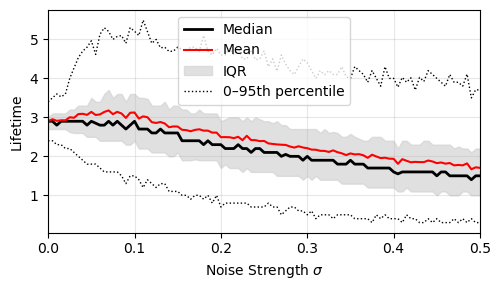

In [30]:
lifetimes = compute_lifetimes_per_sigma(states, sigma_arr)
lifetimes = {k: [vi * dt_compare for vi in v] for k, v in lifetimes.items()}
fig, ax = plot_lifetime_distributions_lines(
    {0: lifetimes}, regime=0, logx=False, xlabel="Noise Strength $\sigma$")
ax.set_xlim(0, 0.5)
plt.savefig("../../Toy_Lifetimes.png", dpi=600)

### Using Markov Chain

In [31]:
times, states, sigma_arr = simulate_trajectories_per_sigma(
    sigmas=np.array([0.0], dtype=np.float32),
    dt=dt_compare,
    n_steps=int(2e4) - 1,
    reset_sampler=lambda rng, size: uniform_radius_sampler_vectorized(
        rng, size, low=0.01, high=0.1
    ),
    rng=rng,
    save_every=save_every,
    x0=0.05,
    dtype=np.float32
)
sneak = 1000
reset_times_per_path = [
    times[:sneak][np.abs(states[:sneak, j]) > 2] for j in range(states.shape[1])
]

<Axes: title={'center': 'Trajectory with reinsertion on |x|≥1'}, xlabel='time', ylabel='x(t)'>

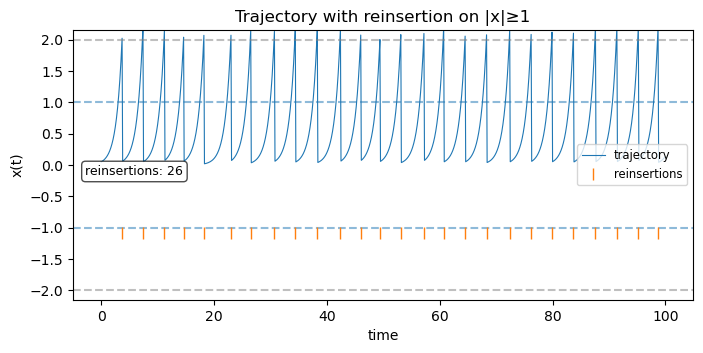

In [32]:
plot_trajectory_with_reinsertions(
    None, times[:sneak], states[:sneak, :], reset_times_per_path[0])

In [ ]:
# 28 min
regime_dict = {}
eps_values = (2 * dt_compare * sigmas**2)
blocking_mask = (np.abs(states) < 1.0).ravel().astype(bool)
resets = np.where(np.abs(states[:, 0]) > 2)[0] + 1
resets_in_block_idx = np.nonzero(
    np.isin(np.nonzero(blocking_mask)[0], resets))[0]
reset_lifetimes = np.empty((resets.shape[0], sigmas.shape[0]))

for i, eps in enumerate(eps_values):
    print(f"Processing epsilon = {eps:.6f}")

    DMM, A = diffusion_maps_matrix_1d(states, eps)

    L = sparse.vstack(
        [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')

    t_escape = expected_escape_times_from_TO_fast(L, blocking_mask)

    reset_lifetimes[:, i] = t_escape[resets_in_block_idx] * dt_compare

    regime_dict[eps] = (t_escape[resets_in_block_idx] * dt_compare).mean()

with open("./Toy_RegimeTimeTO.pkl", "wb") as f:
    pickle.dump(regime_dict, f)

with open("./Toy_ResetLifetimesTO.pkl", "wb") as f:
    pickle.dump(reset_lifetimes, f)

Processing epsilon = 0.000000
Processing epsilon = 0.000005


/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py:2344: RuntimeWarning: invalid value encountered in divide
  A = sparse.coo_matrix((np.exp(-(vals**2) / epsilon),


Processing epsilon = 0.000020
Processing epsilon = 0.000045
Processing epsilon = 0.000080
Processing epsilon = 0.000125
Processing epsilon = 0.000180
Processing epsilon = 0.000245
Processing epsilon = 0.000320
Processing epsilon = 0.000405
Processing epsilon = 0.000500
Processing epsilon = 0.000605
Processing epsilon = 0.000720
Processing epsilon = 0.000845
Processing epsilon = 0.000980
Processing epsilon = 0.001125
Processing epsilon = 0.001280
Processing epsilon = 0.001445
Processing epsilon = 0.001620
Processing epsilon = 0.001805
Processing epsilon = 0.002000
Processing epsilon = 0.002205
Processing epsilon = 0.002420
Processing epsilon = 0.002645
Processing epsilon = 0.002880
Processing epsilon = 0.003125
Processing epsilon = 0.003380
Processing epsilon = 0.003645
Processing epsilon = 0.003920
Processing epsilon = 0.004205
Processing epsilon = 0.004500
Processing epsilon = 0.004805
Processing epsilon = 0.005120
Processing epsilon = 0.005445
Processing epsilon = 0.005780
Processing

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_38593/2715906849.py:9: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")


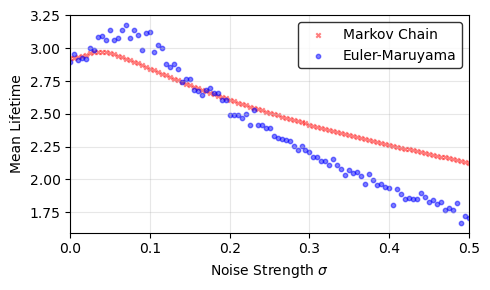

In [ ]:
with open("./Toy_RegimeTimeTO.pkl", "rb") as f:
    regime_dict = pickle.load(f)

with open("./Toy_ResetLifetimesTO.pkl", "rb") as f:
    reset_lifetimes = pickle.load(f)

means = np.array([np.mean(v) for k, v in sorted(lifetimes.items())])
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(np.sqrt(np.array(sorted(regime_dict.keys())) / (dt_compare*2)),
           np.array([regime_dict[k]
                     for k in sorted(regime_dict.keys())]),
           color='red', marker='x', s=10, alpha=.5, label='Markov Chain')
ax.scatter(np.asarray(sorted(lifetimes.keys()), dtype=float), means,
           color='blue', s=10, alpha=0.5, label='Euler-Maruyama')
ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Mean Lifetime")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 0.5)
# ax_rate = ax.twinx()
# ax_rate.scatter(np.sqrt(np.array(sorted(escape_rate_dict.keys()))/(dt*2)),
#                 np.array([escape_rate_dict[k]
#                           for k in sorted(escape_rate_dict.keys())]),
#                 color='green', marker='s', s=10, alpha=.5, label='Escape Rate')
# ax_rate.set_ylabel("Max. Eigenvalue")
# handles1, labels1 = ax.get_legend_handles_labels()
# handles2, labels2 = ax_rate.get_legend_handles_labels()

# # Combine them
# handles = handles1 + handles2
# labels = labels1 + labels2

# # Make a single legend
# ax.legend(handles, labels, facecolor='white',
#           edgecolor='black', loc='best')

ax.legend(facecolor='white', edgecolor='black', loc='best')
plt.tight_layout()

## Now the TO methods

In [74]:
times, states, sigma_arr = simulate_trajectories_per_sigma(
    sigmas=np.array([0.0], dtype=np.float32),
    dt=dt,
    n_steps=int(2e4) - 1,
    reset_sampler=uniform_radius_sampler_vectorized,
    rng=rng,
    save_every=save_every,
    x0=0.05,
    dtype=np.float32
)
reset_times_per_path = [
    times[np.abs(states[:, j]) > 2] for j in range(states.shape[1])]

### Super small example

In [175]:
first_reset = np.where(np.abs(states[:, 0]) > 2)[0][0]
mini_traj = states[np.linspace(0, first_reset, num=10, dtype=int), 0]
blocking_mask = np.where(np.abs(mini_traj) < 1.0)[0]
print(mini_traj)

[0.1        0.13937528 0.19444905 0.2712851  0.37848264 0.52803904
 0.73669225 1.0277941  1.4339242  2.0005355 ]


<Axes: >

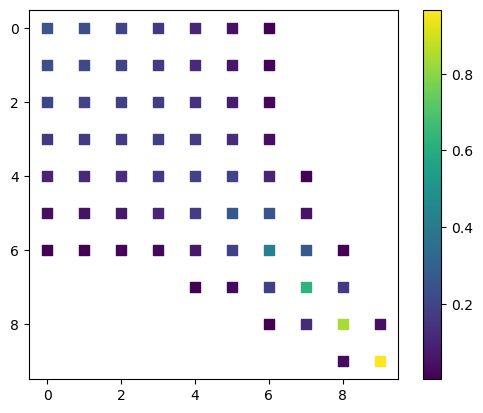

In [176]:
DMM, A = diffusion_maps_matrix_1d(mini_traj, 1e-1)
coo = DMM.tocoo()
spy_col(DMM)

<Axes: >

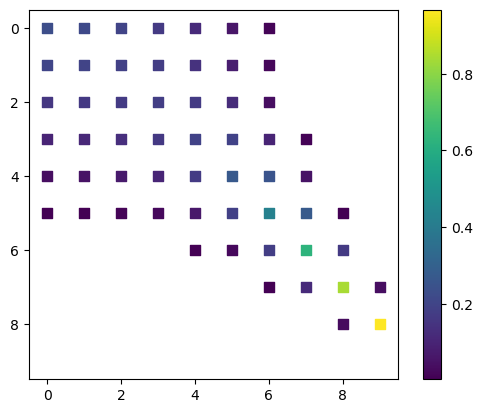

In [177]:
L = sparse.vstack(
    [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')
spy_col(L)

<Axes: >

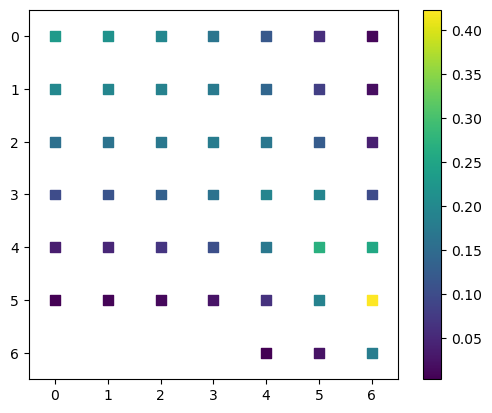

In [179]:

Q = L[blocking_mask][:,
                     blocking_mask].tocsr()
spy_col(Q)

In [180]:
I = sparse.eye(Q.shape[0], format='csr')
t_escape = spsolve(I - Q, np.ones(Q.shape[0]))
t_escape

array([7.01483265, 6.81246438, 6.44993549, 5.733082  , 4.41889096,
       2.62203548, 1.31198586])

In [181]:
first_reset

np.int64(2996)

In [182]:
eps_values[-1]

np.float64(0.1498)

In [183]:
# new dt because of effective subsampling
dt_eff = dt * first_reset/10
eps_values = (2 * (dt_eff) * sigmas**2)

In [184]:
t_escape = []
for eps in eps_values:
    DMM, A = diffusion_maps_matrix_1d(mini_traj, eps)
    L = sparse.vstack(
        [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')
    Q = L[blocking_mask][:, blocking_mask].tocsr()
    I = sparse.eye(Q.shape[0], format='csr')
    t_escape.append(spsolve(I - Q, np.ones(Q.shape[0])))
t_escape = np.array(t_escape)  # shape (n_epsilons, n_states_inside)

/tmp/ipykernel_36339/454216667.py:61: RuntimeWarning: invalid value encountered in divide
  A = sparse.coo_matrix((np.exp(-(vals**2) / epsilon),


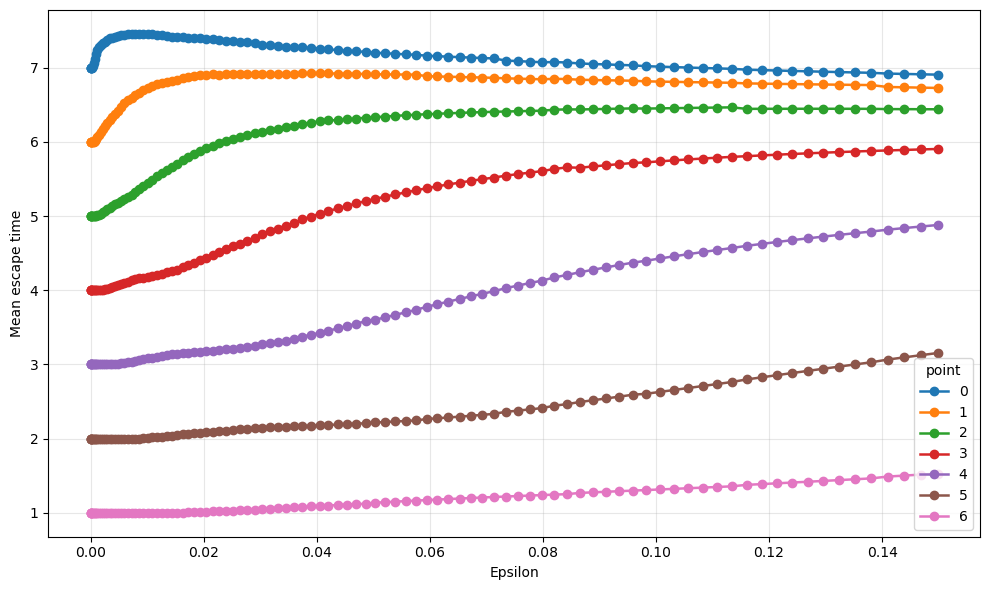

In [186]:
fig, ax = plt.subplots(figsize=(10, 6))
for j in range(t_escape.shape[1]):
    ax.plot(eps_values, t_escape[:, j], marker='o', linewidth=1.8,
            label=f"{j}")

ax.set_xlabel("Epsilon")
ax.set_ylabel("Mean escape time")
ax.grid(True, alpha=0.3)
ax.legend(title="point", loc="best")
plt.tight_layout()

In [ ]:
regime_dict = {}
escape_rate_dict = {}
for eps in eps_values:

    DMM, A = diffusion_maps_matrix_1d(mini_traj, eps)
    L = sparse.vstack(
        [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')
    Q = L[blocking_mask][:, blocking_mask].tocsr()
    try:
        eigval, _ = eigs(Q, k=1, which='LM')
        escape_rate_dict[eps] = eigval.real[0]
    except Exception as e:
        escape_rate_dict[eps] = np.nan
    I = sparse.eye(Q.shape[0], format='csr')
    t_escape = spsolve(I - Q, np.ones(Q.shape[0]))

    p0 = np.zeros_like(mini_traj, dtype=float)
    p0[0] = 1
    p1 = p0 @ L
    p_regime = p1[blocking_mask]
    p_enter = p_regime / p_regime.sum()
    regime_dict[eps] = np.dot(p_enter, t_escape)

[0. 1. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0.]
[0.015674 0.984326 0.       0.       0.       0.       0.      ]
[0.05340493 0.94659507 0.         0.         0.         0.
 0.        ]
[0.10757002 0.87668639 0.01574359 0.         0.         0.
 0.        ]
[0.16361126 0.79632056 0.04006817 0.         0.         0.
 0.        ]
[0.21196406 0.71475818 0.07327776 0.         0.         0.
 0.        ]
[0.249837   0.64087708 0.10928591 0.         0.         0.
 0.        ]
[0.27764398 0.58005873 0.14229729 0.         0.         0.
 0.        ]
[0.29844145 0.53137865 0.1701799  0.         0.         0.
 0.        ]
[0.3139733  0.49370777 0.19231894 0.         0.         0.
 0.        ]
[0.32573874 0.46489795 0.2093633  0.         0.         0.
 0.        ]
[0.33476496 0.44292982 0.22230522 0.         0.         0.
 0.        ]
[0.33990248 0.42170566 0.23084787 0.007544   0.         0.
 0.        ]
[0.3441771  0.40632742 0.237

/tmp/ipykernel_36339/454216667.py:61: RuntimeWarning: invalid value encountered in divide
  A = sparse.coo_matrix((np.exp(-(vals**2) / epsilon),


In [194]:
dt_eff/dt

np.float64(299.59999999999997)

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_36339/2156026022.py:9: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")
/tmp/ipykernel_36339/2156026022.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Lifetime/$\mathrm{dt}$")


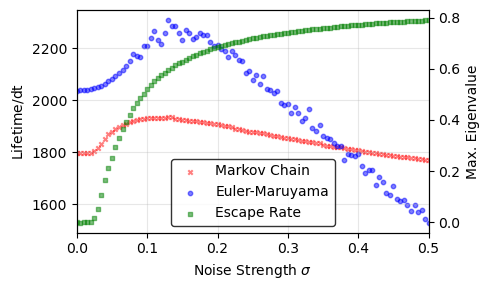

In [196]:
means = np.array([np.mean(v) for k, v in sorted(lifetimes.items())])
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(np.sqrt(np.array(sorted(regime_dict.keys())) / (dt_eff*2)),
           np.array([regime_dict[k] * dt_eff/dt
                     for k in sorted(regime_dict.keys())]),
           color='red', marker='x', s=10, alpha=.5, label='Markov Chain')
ax.scatter(np.asarray(sorted(lifetimes.keys()), dtype=float), means,
           color='blue', s=10, alpha=0.5, label='Euler-Maruyama')
ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Lifetime/$\mathrm{dt}$")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 0.5)
ax_rate = ax.twinx()
ax_rate.scatter(np.sqrt(np.array(sorted(escape_rate_dict.keys()))/(dt_eff*2)),
                np.array([escape_rate_dict[k]
                          for k in sorted(escape_rate_dict.keys())]),
                color='green', marker='s', s=10, alpha=.5, label='Escape Rate')
ax_rate.set_ylabel("Max. Eigenvalue")
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax_rate.get_legend_handles_labels()

# Combine them
handles = handles1 + handles2
labels = labels1 + labels2

# Make a single legend
ax.legend(handles, labels, facecolor='white',
          edgecolor='black', loc='lower center')

plt.tight_layout()

### Make Reinsertion Plot with TO

In [225]:
rng = np.random.default_rng(12345)
times, states, sigma_arr = simulate_trajectories_per_sigma(
    sigmas=np.array([0.0], dtype=np.float32),
    dt=dt,
    n_steps=10000 - 1,
    reset_sampler=constant_reset_sampler_factory(0.05, dtype=np.float32),
    rng=rng,
    save_every=save_every,
    x0=0.01,
    dtype=np.float32
)
first_reset = np.where(np.abs(states[:, 0]) > 2)[0][0]
mini_traj = states[np.linspace(0, first_reset, num=50, dtype=int), 0]
blocking_mask = np.where(np.abs(mini_traj) < 1.0)[0]
print(mini_traj)

[0.01       0.01114048 0.01241102 0.01382647 0.01540335 0.01716007
 0.01911714 0.02131871 0.02375006 0.0264587  0.02947626 0.03283796
 0.03658305 0.04075527 0.04544874 0.05063206 0.05640654 0.06283958
 0.07000629 0.07799035 0.08688497 0.09689085 0.10794103 0.12025146
 0.13396586 0.14924438 0.16626535 0.18522754 0.2065588  0.23011635
 0.25636062 0.28559795 0.31816977 0.3544563  0.39488125 0.4403567
 0.49057838 0.54652774 0.608858   0.67829686 0.7556551  0.84183586
 0.93878365 1.0458498  1.1651267  1.2980068  1.4460415  1.6109592
 1.7946855  2.0013657 ]


In [ ]:

reinsert_TO = np.empty(
    (sigmas.size, reinsertion_points.size), dtype=np.float64)
for i, x in enumerate(reinsertion_points):
    dt_eff = dt * first_reset/50
    eps_values = (2 * (dt_eff) * sigmas**2)
    for j, eps in enumerate(eps_values):

        DMM, A = diffusion_maps_matrix_1d(mini_traj, eps)
        L = sparse.vstack(
            [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')
        Q = L[blocking_mask][:, blocking_mask].tocsr()
        I = sparse.eye(Q.shape[0], format='csr')
        t_escape = spsolve(I - Q, np.ones(Q.shape[0]))
        reinsert_TO[j, :] = t_escape[15:22] * dt_eff/dt

/tmp/ipykernel_36339/454216667.py:61: RuntimeWarning: invalid value encountered in divide
  A = sparse.coo_matrix((np.exp(-(vals**2) / epsilon),


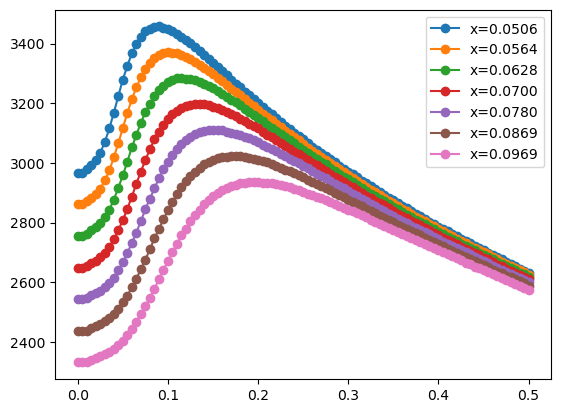

In [230]:
for k in range(reinsert_TO.shape[1]):
    plt.plot(sigmas, reinsert_TO[:, k], marker='o',
             label=f"x={mini_traj[blocking_mask][15 + k]:.4f}")
plt.legend()

### Try first with traj ending at 1

In [170]:
small_traj = states[:first_reset, 0]
eps_values = (2 * dt * sigmas**2)
blocking_mask = np.abs(small_traj) < 1.0

In [135]:
from scipy.sparse.linalg import eigs
regime_dict = {}
escape_rate_dict = {}
for eps in eps_values:
    print(f"Processing epsilon = {eps:.6f}")

    # diffusion_maps_matrix should return a row-stochastic matrix DMM (NxN) and optional affinity A
    DMM, A = diffusion_maps_matrix_1d(small_traj, eps)

    L = sparse.vstack(
        [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')

    # compute expected escape times starting from each "from-node" (length N-1)
    t_escape = expected_escape_times_from_TO_fast(L, blocking_mask)
    p0 = np.zeros_like(small_traj, dtype=float)
    p0[0] = 1
    p1 = p0 @ L
    p_regime = p1[blocking_mask]
    p_enter = p_regime / p_regime.sum()
    regime_dict[eps] = np.dot(p_enter, t_escape)
    Q = L[blocking_mask][:, blocking_mask].tocsr()
    try:
        eigval, _ = eigs(Q, k=1, which='LM')
        escape_rate_dict[eps] = eigval.real[0]
    except Exception as e:
        escape_rate_dict[eps] = np.nan

Processing epsilon = 0.000000


/tmp/ipykernel_36339/454216667.py:61: RuntimeWarning: invalid value encountered in divide
  A = sparse.coo_matrix((np.exp(-(vals**2) / epsilon),


Processing epsilon = 0.000000
Processing epsilon = 0.000000
Processing epsilon = 0.000000
Processing epsilon = 0.000001
Processing epsilon = 0.000001
Processing epsilon = 0.000002
Processing epsilon = 0.000002
Processing epsilon = 0.000003
Processing epsilon = 0.000004
Processing epsilon = 0.000005
Processing epsilon = 0.000006
Processing epsilon = 0.000007
Processing epsilon = 0.000008
Processing epsilon = 0.000010
Processing epsilon = 0.000011
Processing epsilon = 0.000013
Processing epsilon = 0.000014
Processing epsilon = 0.000016
Processing epsilon = 0.000018
Processing epsilon = 0.000020
Processing epsilon = 0.000022
Processing epsilon = 0.000024
Processing epsilon = 0.000026
Processing epsilon = 0.000029
Processing epsilon = 0.000031
Processing epsilon = 0.000034
Processing epsilon = 0.000036
Processing epsilon = 0.000039
Processing epsilon = 0.000042
Processing epsilon = 0.000045
Processing epsilon = 0.000048
Processing epsilon = 0.000051
Processing epsilon = 0.000054
Processing

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_36339/1772925863.py:9: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")
/tmp/ipykernel_36339/1772925863.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Lifetime/$\mathrm{dt}$")


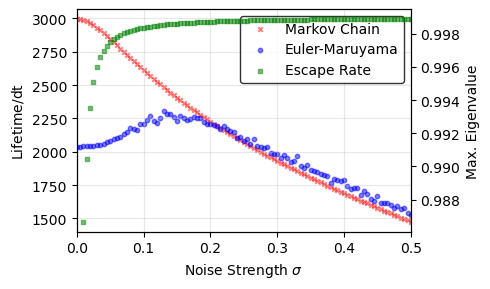

In [161]:
means = np.array([np.mean(v) for k, v in sorted(lifetimes.items())])
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(np.sqrt(np.array(sorted(regime_dict.keys())) / (dt*2)),
           np.array([regime_dict[k]
                     for k in sorted(regime_dict.keys())]),
           color='red', marker='x', s=10, alpha=.5, label='Markov Chain')
ax.scatter(np.asarray(sorted(lifetimes.keys()), dtype=float), means,
           color='blue', s=10, alpha=0.5, label='Euler-Maruyama')
ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Lifetime/$\mathrm{dt}$")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 0.5)
ax_rate = ax.twinx()
ax_rate.scatter(np.sqrt(np.array(sorted(escape_rate_dict.keys()))/(dt*2)),
                np.array([escape_rate_dict[k]
                          for k in sorted(escape_rate_dict.keys())]),
                color='green', marker='s', s=10, alpha=.5, label='Escape Rate')
ax_rate.set_ylabel("Max. Eigenvalue")
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax_rate.get_legend_handles_labels()

# Combine them
handles = handles1 + handles2
labels = labels1 + labels2

# Make a single legend
ax.legend(handles, labels, facecolor='white',
          edgecolor='black', loc='best')

plt.tight_layout()

In [ ]:

with open('./cdv_model/data/dataOro20_TORegdet.pkl', 'rb') as f:
    regime_dict = pickle.load(f)

fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(np.sqrt(np.array(sorted(regime_dict.keys())) / 2),
           np.array([regime_dict[k]
                     for k in sorted(regime_dict.keys())]),
           color='red', marker='x', s=10, alpha=.5, label='Markov Chain')

ax.scatter(np.asarray(sorted(escape_results[0].keys()), dtype=float), means,
           color='blue', s=10, alpha=0.5, label='Euler-Maruyama')
ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Lifetime/$\mathrm{dt}$")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 0.05)

# add the rate
with open('./cdv_model/data/dataOro20_detRate.pkl', 'rb') as f:
    escape_rate_dict = pickle.load(f)

ax_rate = ax.twinx()
ax_rate.scatter(np.sqrt(np.array(sorted(escape_rate_dict.keys()))/2),
                np.array([escape_rate_dict[k]
                          for k in sorted(escape_rate_dict.keys())]),
                color='green', marker='s', s=10, alpha=.5, label='Escape Rate')
ax_rate.set_ylabel("Max. Eigenvalue")
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax_rate.get_legend_handles_labels()

# Combine them
handles = handles1 + handles2
labels = labels1 + labels2

# Make a single legend
ax.legend(handles, labels, facecolor='white', edgecolor='black', loc='right')

plt.tight_layout()
plt.savefig('../../RegimeLifetimesEMvsTO.png', dpi=600)

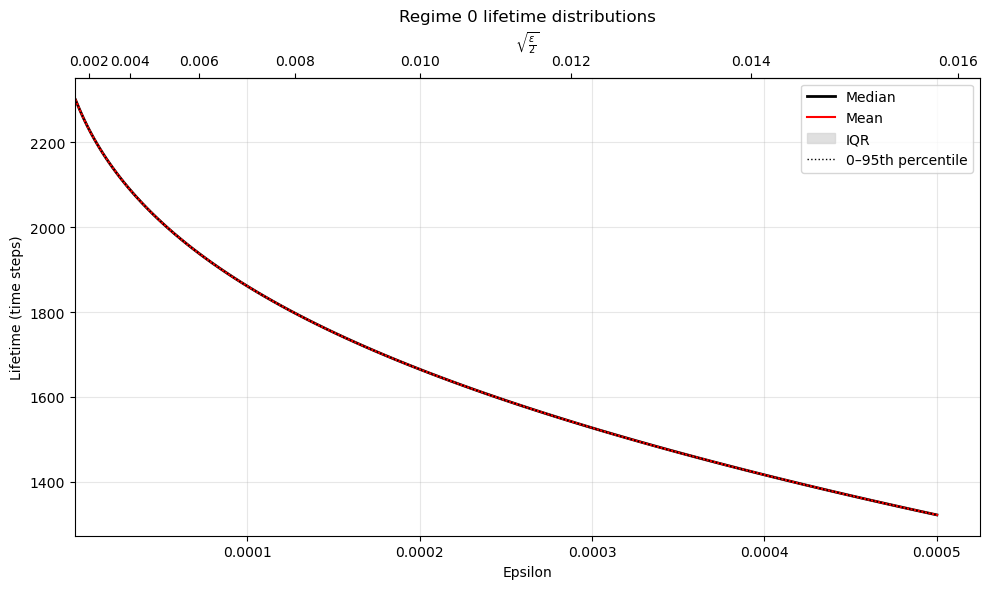

In [159]:
fig, ax = plot_lifetime_distributions_lines(
    {0: t_escape_dict}, regime=0, logx=False, xlabel="Epsilon")
fig, ax = add_scaled_top_axis(fig, ax, sorted(t_escape_dict.keys()))

### Now full trajectory

In [205]:
import pickle
with open('./cdv_model/data/ToyData.pkl', 'wb') as f:
    pickle.dump((regime_dict, escape_rate_dict), f)

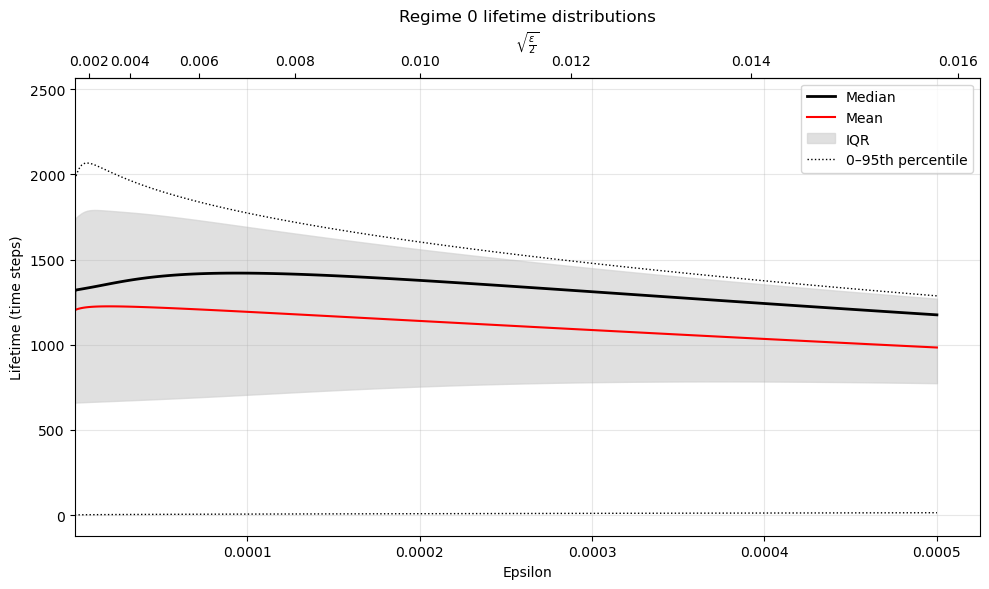

In [139]:
fig, ax = plot_lifetime_distributions_lines(
    {0: t_escape_dict}, regime=0, logx=False, xlabel="Epsilon")
fig, ax = add_scaled_top_axis(fig, ax, sorted(t_escape_dict.keys()))

### Now obtain regime lifetimes

In [20]:
regime_dict = {}

for eps in eps_values:
    print(f"Processing epsilon = {eps:.6f}")

    # diffusion_maps_matrix should return a row-stochastic matrix DMM (NxN) and optional affinity A
    DMM, A = diffusion_maps_matrix_1d(det_traj, eps)
    print(f"DMM shape: {DMM.shape}, nnz: {DMM.nnz}")
    # build one-step transfer operator mapping states at time t -> t+dt
    # shape: (N-1, N-1)
    L = DMM[1:, :-1]

    # compute expected escape times starting from each "from-node" (length N-1)
    t_escape = expected_escape_times_from_TO_fast(L, blocking_mask)

    p0 = np.zeros(len(blocking_mask), dtype=float)
    p0[~blocking_mask] = 1 / \
        (~blocking_mask).sum()
    p1 = p0 @ L
    p_regime = p1[blocking_mask]
    p_enter = p_regime / p_regime.sum()
    regime_dict[eps] = np.dot(p_enter, t_escape)

Processing epsilon = 0.000025
DMM shape: (10000, 10000), nnz: 3835056
Processing epsilon = 0.000100
DMM shape: (10000, 10000), nnz: 7560736
Processing epsilon = 0.000225
DMM shape: (10000, 10000), nnz: 11132234
Processing epsilon = 0.000400
DMM shape: (10000, 10000), nnz: 14536503
Processing epsilon = 0.000625
DMM shape: (10000, 10000), nnz: 17751260
Processing epsilon = 0.000900
DMM shape: (10000, 10000), nnz: 20797154
Processing epsilon = 0.001225
DMM shape: (10000, 10000), nnz: 23692650
Processing epsilon = 0.001600
DMM shape: (10000, 10000), nnz: 26452956
Processing epsilon = 0.002025
DMM shape: (10000, 10000), nnz: 29090907


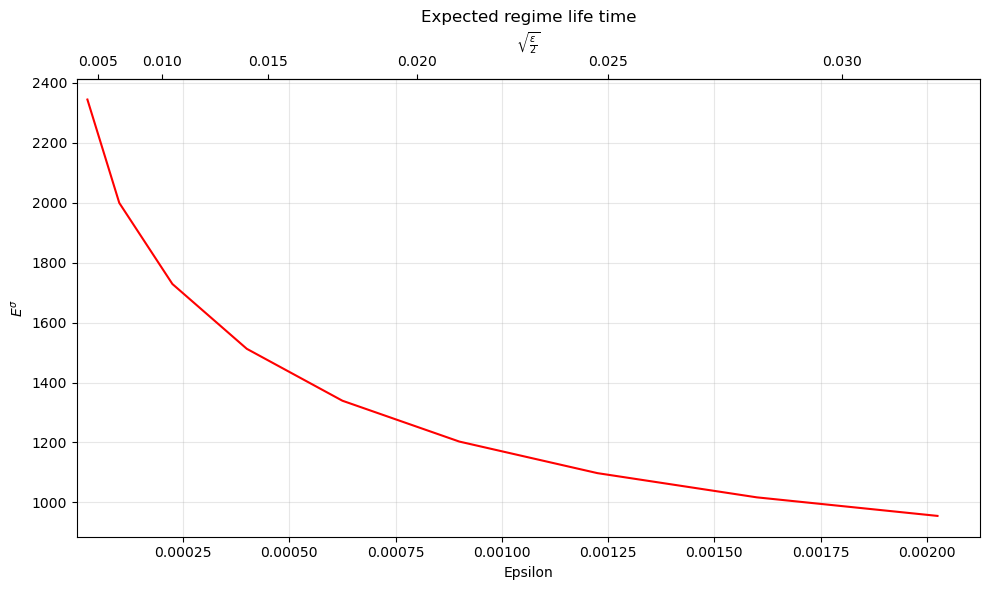

In [21]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.array(sorted(regime_dict.keys())),
        np.array([regime_dict[k]
                 for k in sorted(regime_dict.keys())]),
        color='red', linewidth=1.5)
ax.set_xlabel("Epsilon")
ax.set_ylabel("$E^{\\sigma}$")
ax.set_title("Expected regime life time")
ax.grid(True, alpha=0.3)

fig, ax = add_scaled_top_axis(fig, ax, sorted(regime_dict.keys()))
plt.tight_layout()

In [6]:
fig, ax = plot_lifetime_distributions_lines(
    {0: t_escape_dict}, regime=0, logx=False, xlabel="Epsilon")
fig, ax = add_scaled_top_axis(fig, ax, sorted(t_escape_dict.keys()))

NameError: name 't_escape_dict' is not defined

In [22]:
sigma_arr

array([0.], dtype=float32)

In [18]:
states.shape

(100000, 1)

In [17]:
reset_times_per_path[0].shape

(38,)

In [ ]:
states.shape

(10000000,)

In [ ]:
np.where(jump_times[0] == times)[0][0]

np.int64(2304)

In [ ]:
det_traj = states[:np.where(jump_times[0] == times)[0][0]].reshape(-1, 1)
block_mask = (np.abs(det_traj) >= 1.0)[1:]

In [ ]:
block_mask

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [ True]], shape=(2304, 1))

In [ ]:
L

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 124851 stored elements and shape (2303, 2303)>

In [ ]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.sparse import eye
DMM, A = diffusion_maps_matrix(det_traj, eps)
L = DMM[1:, :-1]
L.shape
Q = L[:-1, :][:, :-1].tocsr()
I = eye(Q.shape[0], format='csr')
t_escape = spsolve(I - Q, np.ones(Q.shape[0]))
p0 = np.zeros_like(block_mask, dtype=float)
p0[block_mask] = 1 / \
    (block_mask).sum()
print(f"shape p0: {p0.shape}, sum p0: {p0.sum()}, shape L: {L.shape}")
p1 = p0.T @ L
p_regime = p1[not (block_mask.T)]
p_enter = p_regime / p_regime.sum()
t_escape_dict[eps] = np.dot(p_enter, t_escape)

shape p0: (2303, 1), sum p0: 1.0, shape L: (2303, 2303)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
p1[(block_mask == False).T]

array([0.        , 0.        , 0.        , ..., 0.04669165, 0.0973995 ,
       0.17383181], shape=(2302,))

In [ ]:
block_mask.T.shape

(1, 2303)

In [ ]:
p1

array([[0.        , 0.        , 0.        , ..., 0.0973995 , 0.17383181,
        0.2720529 ]], shape=(1, 2303))

In [ ]:
t_escape_dict = {}

for eps in np.linspace(0, 0.005, 501)[1:]:
    DMM, A = diffusion_maps_matrix(det_traj, eps)
    L = DMM[1:, :-1]
    L.shape
    Q = L[:-1, :][:, :-1].tocsr()
    from scipy.sparse import eye
    from scipy.sparse.linalg import spsolve
    from scipy.sparse import csr_matrix
    I = eye(Q.shape[0], format='csr')
    t_escape = spsolve(I - Q, np.ones(Q.shape[0]))
    p0 = np.zeros_like(block_mask, dtype=float)
    p0[block_mask] = 1 / \
        (block_mask).sum()
    p1 = p0.T @ L
    p_regime = p1[(block_mask == False).T]
    p_enter = p_regime / p_regime.sum()
    t_escape_dict[eps] = np.dot(p_enter, t_escape)

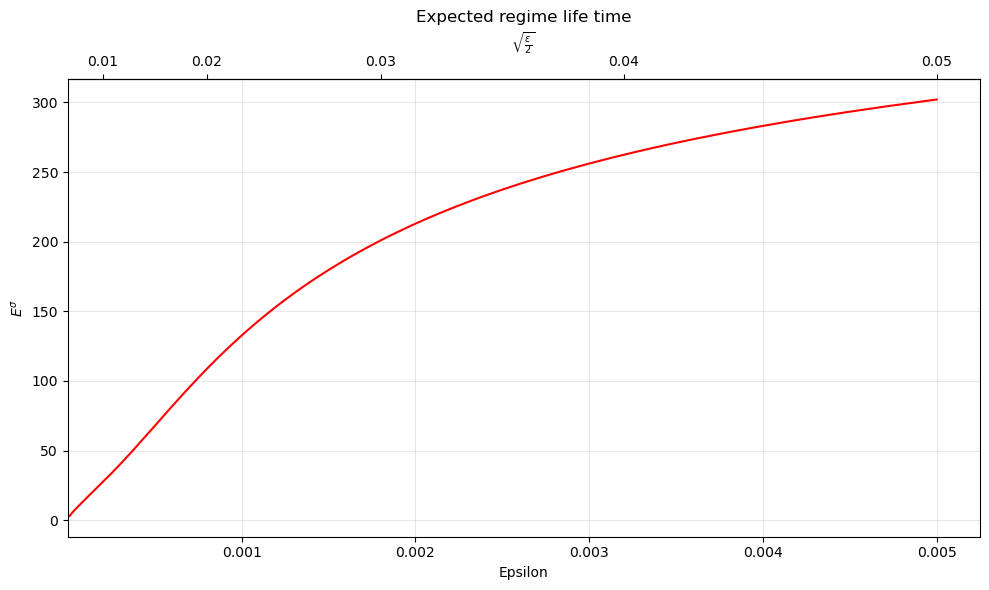

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.linspace(0, 0.005, 501)[1:501],
        np.array([t_escape_dict[k]
                 for k in sorted(t_escape_dict.keys())]),
        color='red', linewidth=1.5)
ax.set_xlabel("Epsilon")
ax.set_ylabel("$E^{\\sigma}$")
ax.set_title("Expected regime life time")
ax.grid(True, alpha=0.3)

fig, ax = add_scaled_top_axis(fig, ax, sorted(t_escape_dict.keys()))
plt.tight_layout()

In [ ]:
t_escape

array([1888.77672817, 1888.76539513, 1888.75458121, ...,   12.41725153,
         11.84252021,   11.29969133], shape=(2302,))

In [ ]:
t_escape_dict = {}

for eps in np.linspace(0, 0.005, 501)[1:10]:
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(det_traj, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator
    L = DMM[1:, :-1]

    # Compute expected escape times for the blocking set
    t_escape = expected_escape_times_from_TO(
        L, (np.abs(det_traj) >= 1.0))  # [:-1])

    # Store
    t_escape_dict[eps] = t_escape

Processing epsilon = 0.000010
Processing epsilon = 0.000020
Processing epsilon = 0.000030
Processing epsilon = 0.000040
Processing epsilon = 0.000050
Processing epsilon = 0.000060
Processing epsilon = 0.000070
Processing epsilon = 0.000080
Processing epsilon = 0.000090


In [ ]:
t_escape_dict

{np.float64(0.001): array([1074.48053359, 1074.47733018, 1074.47380361, ...,  122.67473166,
         122.02375652,  121.38032256], shape=(2302,)),
 np.float64(0.002): array([812.51019863, 812.5076652 , 812.50537384, ..., 200.70211657,
        200.16483583, 199.63134915], shape=(2302,)),
 np.float64(0.003): array([692.89176793, 692.88989512, 692.8880158 , ..., 243.78365488,
        243.34241284, 242.9101526 ], shape=(2302,)),
 np.float64(0.004): array([626.01414177, 626.01229573, 626.01066092, ..., 271.21020845,
        270.84876288, 270.48880533], shape=(2302,)),
 np.float64(0.005): array([584.04992989, 584.04825931, 584.04679146, ..., 290.60128974,
        290.2925228 , 289.98480924], shape=(2302,)),
 np.float64(0.006): array([555.72703378, 555.72569382, 555.72414822, ..., 305.32348837,
        305.05405663, 304.78540698], shape=(2302,)),
 np.float64(0.007): array([535.65092036, 535.64947925, 535.64823104, ..., 317.09780096,
        316.85874074, 316.62028179], shape=(2302,)),
 np.flo

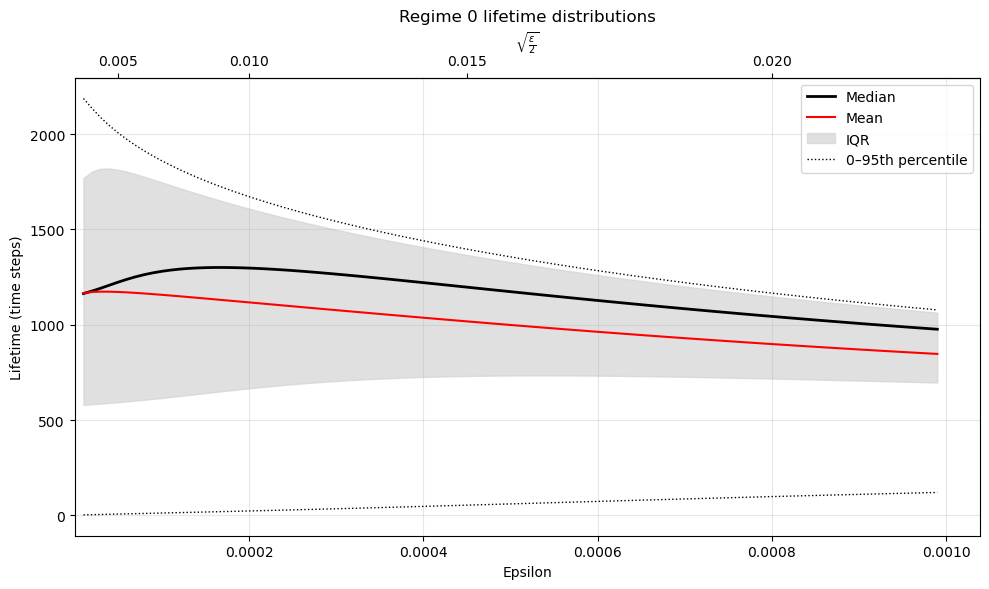

In [ ]:
fig, ax = plot_lifetime_distributions_lines(
    {0: t_escape_dict}, regime=0, logx=False, xlabel="Epsilon")
fig, ax = add_scaled_top_axis(fig, ax, sorted(t_escape_dict.keys()))

In [ ]:
# deterministic trajectory
det_traj = states.reshape(-1, 1)
t_escape_dict = {}
for eps in np.linspace(0, 0.005, 501)[1:10]:
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(det_traj, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator
    L = DMM[1:, :-1]

    # Compute expected escape times for the blocking set
    t_escape = expected_escape_times_from_TO(L, det_traj)

    # Store
    t_escape_dict[eps] = t_escape

fig, ax = plot_lifetime_distributions_lines(
    {0: t_escape_dict}, regime=0, logx=False, xlabel="Epsilon")
fig, ax = add_scaled_top_axis(fig, ax, sorted(t_escape_dict.keys()))

Processing epsilon = 0.000010


: 

In [ ]:
regime_dict = {}
for eps in np.linspace(0, 0.005, 501)[1:]:
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(det_traj, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator
    L = DMM[1:, :-1]

    # Compute expected escape times for the blocking set
    t_escape = t_escape_dict[eps]
    p0 = np.zeros(len(det_traj))
    p0[det_traj == 0] = 1 / (det_traj == 0).sum()
    p1 = p0 @ L
    p_regime = p1[det_traj == 1]
    p_enter = p_regime / p_regime.sum()
    regime_dict[eps] = np.dot(p_enter, t_escape)


fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.array(sorted(regime_dict.keys())),
        np.array([regime_dict[k]
                 for k in sorted(regime_dict.keys())]),
        color='red', linewidth=1.5)
ax.set_xlabel("Epsilon")
ax.set_ylabel("$E^{\\sigma}$")
ax.set_title("Expected regime life time")
ax.grid(True, alpha=0.3)

fig, ax = add_scaled_top_axis(fig, ax, sorted(regime_dict.keys()))
plt.tight_layout()

In [ ]:
escape_rate_dict = {}
for eps in np.linspace(0, 0.005, 501)[1:]:
    print(f"Processing epsilon = {eps:.6f}")
    # Compute diffusion matrix for this epsilon
    DMM, A = diffusion_maps_matrix(det_traj, eps)  # row-stochastic

    # Build one-step deterministic + diffusion transfer operator and transpose
    L = DMM[1:, :-1]

    Q = L[det_cluster_res["labels"] == 1, :][:, det_cluster_res["labels"] == 1]
    eigval, _ = eigs(Q, k=1, which='LM')
    # Store
    escape_rate_dict[eps] = eigval.real[0]

# Legacy

In [ ]:
import numpy as np
from typing import Callable, Optional, Tuple

ResetSampler = Callable[[np.random.Generator], float]


def dxdt(x: float) -> float:
    return x


def midpoint_step(x: float,
                  dt: float,
                  sigma: float,
                  rng: np.random.Generator,
                  reset_sampler: ResetSampler) -> Tuple[float, bool]:
    """
    One midpoint-style step (deterministic RK2 on drift + additive noise).
    Returns (x_new, jumped) where jumped is True if reinsertion occurred.
    """
    if abs(x) >= 1.0:
        X_new = np.sign(x)*reset_sampler(rng)
        return float(X_new), True
    dW = rng.normal(loc=0.0, scale=np.sqrt(dt))
    k1 = dt * dxdt(x)
    k2 = dt * dxdt(x + 0.5 * k1)
    x_new = x + k2 + sigma * dW

    return float(x_new), False


def integrate_midpoint(dt: float,
                       save_interval: float,
                       sigma: float,
                       n_steps: int,
                       x0: float,
                       reset_sampler: ResetSampler,
                       rng: np.random.Generator
                       ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Integrate using the refactored midpoint scheme up to n_steps and also
    return reinsertion times and post-reinsertion states.

    Returns:
      times, states, jump_times, jump_states
    where jump_times/jump_states are 1D numpy arrays (possibly empty).
    """

    if save_interval <= 0 or save_interval < dt:
        save_every = 1
    else:
        save_every = max(1, int(round(save_interval / dt)))

    max_saves = (n_steps // save_every) + 1
    times = np.empty(max_saves, dtype=float)
    states = np.empty(max_saves, dtype=float)

    jump_times = []

    x = float(x0)
    t = 0.0
    save_idx = 0

    # Save initial state
    times[save_idx] = t
    states[save_idx] = x
    save_idx += 1

    for step in range(1, n_steps + 1):
        x, jumped = midpoint_step(x, dt, sigma, rng, reset_sampler)
        t += dt

        if jumped:
            jump_times.append(t)

        if (step % save_every) == 0:
            times[save_idx] = t
            states[save_idx] = x
            save_idx += 1

    # Trim arrays
    times = times[:save_idx]
    states = states[:save_idx]
    jump_times = np.array(jump_times, dtype=float)

    return times, states, jump_times


# ---- Example reset samplers ----
def uniform_reset_sampler(rng: np.random.Generator) -> float:
    """Uniform reinsertion on [-1,1]."""
    return rng.uniform(0.05, 0.1)


def beta_symmetric_reset_sampler(rng: np.random.Generator, a: float = 2.0, b: float = 2.0) -> float:
    """Symmetric Beta reinsertion on [-1,1]."""
    u = rng.beta(a, b)
    sign = -1.0 if rng.random() < 0.5 else 1.0
    return sign * u

In [ ]:
# DROP-IN replacement for `integrate_midpoint` (paste this cell)
import math
import numpy as np
from numba import njit
from typing import Callable, Optional, Tuple

ResetSampler = Callable[[np.random.Generator], float]


@njit(cache=True)
def _integrate_midpoint_numba(dt: float,
                              sigma: float,
                              n_steps: int,
                              save_every: int,
                              x0: float,
                              dW: np.ndarray,
                              reset_samples: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Numba hot-loop. Returns (times, states, jump_times).
    Behavior matches your Python version: if |x|>=1 at start of step, reset to sign(x)*reset_sample.
    """
    max_saves = (n_steps // save_every) + 1
    times = np.empty(max_saves, dtype=np.float64)
    states = np.empty(max_saves, dtype=np.float64)

    jump_times = np.empty(n_steps, dtype=np.float64)  # will trim
    jump_idx = 0
    reset_idx = 0

    x = float(x0)
    t = 0.0
    save_idx = 0

    # Save initial state
    times[save_idx] = t
    states[save_idx] = x
    save_idx += 1

    for i in range(n_steps):
        # reset if outside at start of step (preserve sign)
        if x >= 1.0 or x <= -1.0:
            sign = 1.0 if x >= 0.0 else -1.0
            x = sign * reset_samples[reset_idx]
            reset_idx += 1
            jumped = True
        else:
            # midpoint RK2 for dxdt(x) = x
            k1 = dt * x
            k2 = dt * (x + 0.5 * k1)
            x = x + k2 + sigma * dW[i]
            jumped = False

        # Advance time (same ordering as your Python)
        t += dt

        if jumped:
            jump_times[jump_idx] = t
            jump_idx += 1

        if ((i + 1) % save_every) == 0:
            times[save_idx] = t
            states[save_idx] = x
            save_idx += 1

    # trim arrays
    times = times[:save_idx].copy()
    states = states[:save_idx].copy()
    jump_times = jump_times[:jump_idx].copy()

    return times, states, jump_times


def integrate_midpoint(dt: float,
                       save_interval: float,
                       sigma: float,
                       n_steps: int,
                       x0: float,
                       reset_sampler: ResetSampler,
                       rng: np.random.Generator
                       ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Drop-in replacement that uses a Numba inner loop.
    Signature and return values match your original function:
      returns (times, states, jump_times)
    """
    if save_interval <= 0 or save_interval < dt:
        save_every = 1
    else:
        save_every = max(1, int(round(save_interval / dt)))

    # Precompute increments and reset samples in Python (keeps RNG use identical to before)
    sqrt_dt = math.sqrt(dt)
    dW = rng.normal(loc=0.0, scale=sqrt_dt, size=n_steps).astype(np.float64)

    reset_samples = np.empty(n_steps, dtype=np.float64)
    for i in range(n_steps):
        # reset_sampler uses the same rng you pass in
        reset_samples[i] = reset_sampler(rng)

    # Call the compiled integrator
    times, states, jump_times = _integrate_midpoint_numba(
        float(dt),
        float(sigma),
        int(n_steps),
        int(save_every),
        float(x0),
        dW,
        reset_samples
    )

    return times, states, jump_times

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# parameters
dt = 1e-3
save_interval = 1e-3   # save every 2 time units
sigma = 0
n_steps = 1000000 - 1
x0 = 0.1
rng = np.random.default_rng(42)

# run the integrator from Cell 1
times, states, jump_times = integrate_midpoint(
    dt=dt,
    save_interval=save_interval,
    sigma=sigma,
    n_steps=n_steps,
    x0=x0,
    reset_sampler=uniform_reset_sampler,
    rng=rng
)

In [ ]:
from typing import Callable, Optional, Dict, Any, Tuple


def simulate_over_sigmas(sigmas: np.ndarray,
                         dt: float,
                         save_interval: float,
                         n_steps: int,
                         x0: float,
                         reset_sampler: Callable[[np.random.Generator], float],
                         rng_seed: Optional[int] = None
                         ) -> Tuple[np.ndarray, Dict[float, Dict[str, np.ndarray]]]:
    """
    Run integrate_midpoint for each sigma in `sigmas` and return:
      times, results_dict

    - `times` is the common time vector returned by integrate_midpoint.
    - `results_dict` maps each sigma (float) -> {'states': np.ndarray, 'jump_times': np.ndarray, 'jump_states': np.ndarray}

    Requirements:
      - `integrate_midpoint(dt, save_interval, sigma, n_steps, x0, reset_sampler, rng)`
        must be defined in the namespace and return (times, states, jump_times, jump_states).
    Reproducibility:
      - If rng_seed is not None, each sigma run uses seed = rng_seed + i (i = index).
    """
    sigmas = np.asarray(sigmas, dtype=float)
    results: Dict[float, Dict[str, np.ndarray]] = {}
    common_times: Optional[np.ndarray] = None

    for i, sigma in enumerate(sigmas):
        seed = None if rng_seed is None else int(rng_seed) + i
        rng = np.random.default_rng(seed)

        # integrate_midpoint is expected to return (times, states, jump_times)
        t_vec, states, jump_times = integrate_midpoint(
            dt=dt,
            save_interval=save_interval,
            sigma=float(sigma),
            n_steps=n_steps,
            x0=x0,
            reset_sampler=reset_sampler,
            rng=rng
        )

        # set/validate common times
        if common_times is None:
            common_times = t_vec

        # store results for this sigma
        results[float(sigma)] = {
            'states': np.asarray(states, dtype=float),
            'jump_times': np.asarray(jump_times, dtype=float)}

    if common_times is None:
        # no sigmas provided
        common_times = np.empty(0, dtype=float)

    return common_times, results

In [ ]:
import pickle
times, data = simulate_over_sigmas(
    sigmas=np.linspace(0.0, 0.1, 101),
    dt=dt,
    save_interval=save_interval,
    n_steps=n_steps,
    x0=x0,
    reset_sampler=uniform_reset_sampler,
    rng_seed=42
)

0.0
0.001
0.002
0.003
0.004
0.005
0.006
0.007
0.008
0.009000000000000001
0.01
0.011
0.012
0.013000000000000001
0.014
0.015
0.016
0.017
0.018000000000000002
0.019
0.02
0.021
0.022
0.023
0.024
0.025
0.026000000000000002
0.027
0.028
0.029
0.03
0.031
0.032
0.033
0.034
0.035
0.036000000000000004
0.037
0.038
0.039
0.04
0.041
0.042
0.043000000000000003
0.044
0.045
0.046
0.047
0.048
0.049
0.05
0.051000000000000004
0.052000000000000005
0.053
0.054
0.055
0.056
0.057
0.058
0.059000000000000004
0.06
0.061
0.062
0.063
0.064
0.065
0.066
0.067
0.068
0.069
0.07
0.07100000000000001
0.07200000000000001
0.073
0.074
0.075
0.076
0.077
0.078
0.079
0.08
0.081
0.082
0.083
0.084
0.085
0.08600000000000001
0.08700000000000001
0.088
0.089
0.09
0.091
0.092
0.093
0.094
0.095
0.096
0.097
0.098
0.099
0.1


In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import numpy as np
import os


def _worker_call_integrate(args):
    sigma, dt, save_interval, n_steps, x0, reset_sampler, seed = args
    rng = np.random.default_rng(seed)
    t_vec, states, jump_times = integrate_midpoint(
        dt, save_interval, float(sigma), n_steps, x0, reset_sampler, rng
    )
    return float(sigma), t_vec, {
        "states": states,
        "jump_times": jump_times
    }


def simulate_over_sigmas_parallel(sigmas, dt, save_interval, n_steps, x0,
                                  reset_sampler, rng_seed=None, max_workers=None):
    sigmas = np.asarray(sigmas, dtype=float)
    if max_workers is None:
        max_workers = min(len(sigmas), os.cpu_count() - 1 or 1)
    args = []
    for i, sigma in enumerate(sigmas):
        seed = None if rng_seed is None else int(rng_seed) + i
        args.append((sigma, dt, save_interval,
                    n_steps, x0, reset_sampler, seed))
    results = {}
    common_times = None
    with ProcessPoolExecutor(max_workers=max_workers) as exe:
        futures = [exe.submit(_worker_call_integrate, a) for a in args]
        for fut in as_completed(futures):
            sigma_val, t_vec, data = fut.result()
            if common_times is None:
                common_times = t_vec
            results[float(sigma_val)] = data
    if common_times is None:
        common_times = np.empty(0, dtype=float)
    return common_times, results

In [ ]:
times, results = simulate_over_sigmas_parallel(
    sigmas=np.linspace(0.0, 0.1, 101),
    dt=dt,
    save_interval=save_interval,
    n_steps=n_steps,
    x0=x0,
    reset_sampler=uniform_reset_sampler
)

In [ ]:

with open("toy_simulation_data.pkl", "wb") as f:
    pickle.dump((times, data), f)

In [ ]:
def compute_escape_times_from_results(times, results):
    """
    Return dict mapping each sigma to its list of escape times 
    (intervals between reinsertion events).
    """
    return {s: np.diff(np.insert(d['jump_times'], 0, 0.0)).tolist() for s, d in results.items()}

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Regime 0 lifetime distributions'}, xlabel='Sigma', ylabel='Lifetime (time steps)'>)

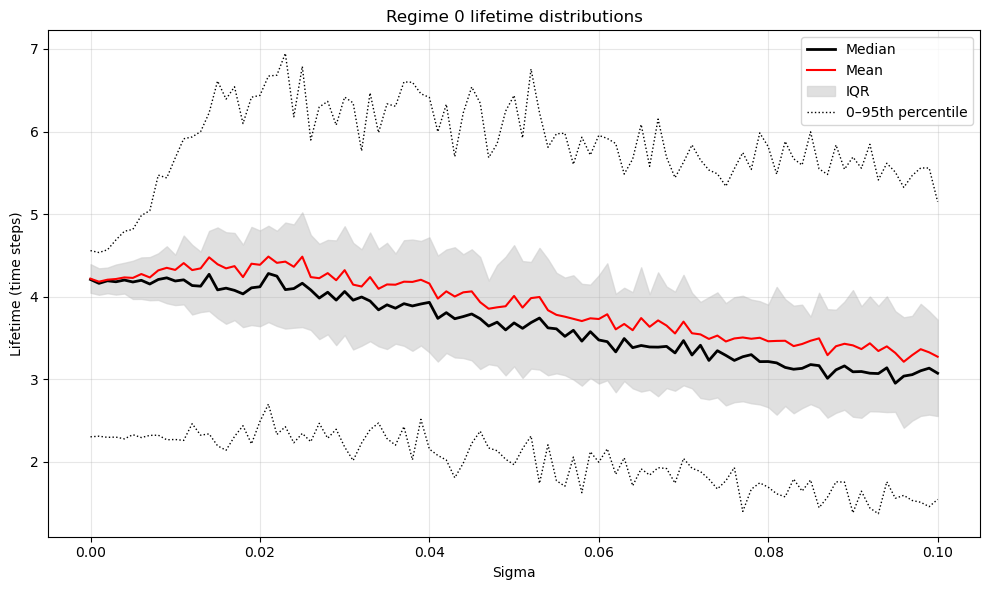

In [ ]:
escape_times = compute_escape_times_from_results(times, states)


plot_lifetime_distributions_lines(
    {0: escape_times}, regime=0, logx=False)

In [64]:
traj = []
dt_low = 1.5e-3
for x in reinsertion_points:
    times, states, sigma_arr = simulate_trajectories_per_sigma(
        sigmas=np.array([0.0], dtype=np.float32),
        dt=dt_low,
        n_steps=10000 - 1,
        reset_sampler=constant_reset_sampler_factory(0.05, dtype=np.float32),
        rng=rng,
        save_every=save_every,
        x0=float(x),
        dtype=np.float32
    )
    first_reset = np.where(np.abs(states[:, 0]) > 2)[0][0]
    mini_traj = states[:first_reset, 0]
    traj.extend(mini_traj)

# convert to 1D array of length 110
traj = np.array(traj, dtype=np.float32)

traj.shape

(10375,)

In [ ]:
eps_values = (2 * (dt_low) * sigmas**2)
blocking_mask = np.where(np.abs(traj) < 1.0)[0]
reinsert_TO = np.empty(
    (sigmas.size, reinsertion_points.size), dtype=np.float64)
rp_idx = [np.argmin(np.abs(traj - rp))
          for rp in reinsertion_points]
for j, eps in enumerate(eps_values):
    DMM, A = diffusion_maps_matrix_1d(traj, eps)
    L = sparse.vstack(
        [DMM[1:], sparse.csr_matrix((1, DMM.shape[1]))], format='csr')
    Q = L[blocking_mask][:, blocking_mask].tocsr()
    I = sparse.eye(Q.shape[0], format='csr')
    t_escape = sparse.linalg.spsolve(I - Q, np.ones(Q.shape[0]))
    reinsert_TO[j, :] = t_escape[rp_idx]

In [75]:
reinsert_TO = reinsert_TO * dt_low/dt_lower

In [ ]:
epsilons = np.logspace(-10, 2, 50)
sums = np.empty(
    (50, 1), dtype=np.float64)
for j, eps in enumerate(epsilons):
    DMM, A = diffusion_maps_matrix_1d(mini_traj, eps)
    sums[j] = A.sum()
plt.plot(epsilons, sums/A.shape[0])
plt.plot(eps_values[1:], np.ones_like(eps_values[1:]), '|', markersize=20)
plt.xscale('log')
plt.yscale('log')